In [1]:
import numpy as np
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [2]:
#load dataset
df= pd.read_csv("bbc_news_dataset.csv")
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ArticleId  1490 non-null   int64
 1   Text       1490 non-null   str  
 2   Category   1490 non-null   str  
dtypes: int64(1), str(2)
memory usage: 35.1 KB
None
   ArticleId                                               Text  Category
0       1833  worldcom ex-boss launches defence lawyers defe...  business
1        154  german business confidence slides german busin...  business
2       1101  bbc poll indicates economic gloom citizens in ...  business
3       1976  lifestyle  governs mobile choice  faster  bett...      tech
4        917  enron bosses in $168m payout eighteen former e...  business


In [3]:
#seperate the features and labels
X= df['Text']
Y= df['Category']

In [4]:
#explore categories
category_names = df['Category'].unique()
print(category_names)
value_counts = df['Category'].value_counts()
print(value_counts)

<StringArray>
['business', 'tech', 'politics', 'sport', 'entertainment']
Length: 5, dtype: str
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


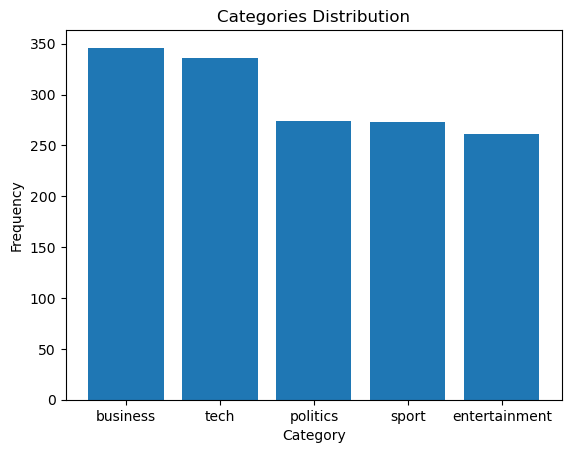

In [5]:
#visualizee categories distribution
plt.bar(x=category_names, height=value_counts)
plt.title('Categories Distribution')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.show()

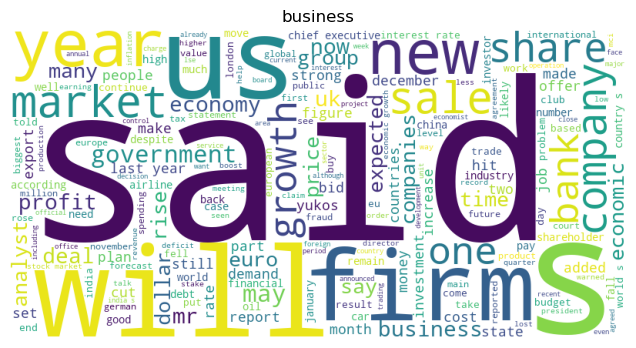

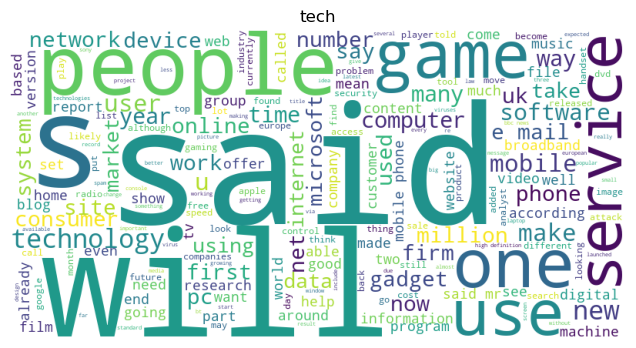

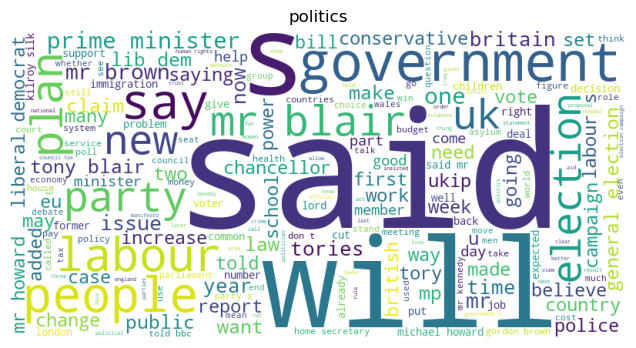

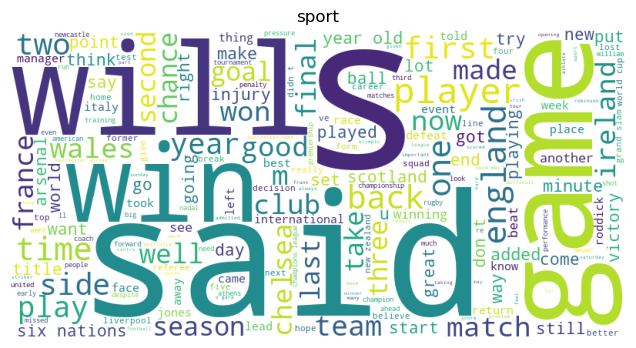

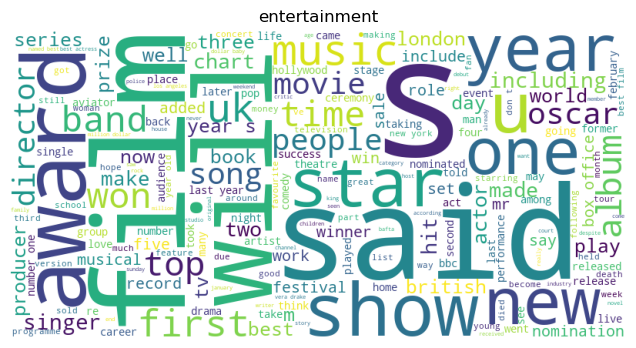

In [6]:
#generate word clouds for each category

for category in category_names:
    text = " ".join(df[df['Category']==category]['Text'].values)
    wc = WordCloud(width=800,height=400,
        background_color='white').generate(text)
    plt.figure(figsize=(8,4))
    plt.imshow(wc)
    plt.axis('off')
    plt.title(category)
    plt.show()

In [7]:
#train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [8]:
# build model
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
model = make_pipeline(
TfidfVectorizer(stop_words='english'),
MultinomialNB()
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [9]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.94      0.97      0.95        75
entertainment       1.00      0.96      0.98        46
     politics       0.91      0.95      0.93        56
        sport       0.97      1.00      0.98        63
         tech       0.98      0.90      0.94        58

     accuracy                           0.96       298
    macro avg       0.96      0.95      0.96       298
 weighted avg       0.96      0.96      0.96       298



Insights
- The model achieved 96% accuracy, showing excellent overall performance.
- Business: Classified accurately with 94% precision, 97% recall, and 0.95 F1-score.
- Entertainment: Best precision (100%) with 96% recall and 0.98 F1-score.
- Politics: Lowest precision (91%) but good recall (95%) and 0.93 F1-score.
- Sport: Best recall (100%) with 97% precision and 0.98 F1-score.
- Technology: Highest precision after entertainment (98%), but lowest recall (90%), giving an F1-score of 0.94.


Overall Conclusion
- The classifier performs well across all five categories with 96% accuracy and a 0.96 weighted F1-score. It performs best on sport and entertainment,
   while politics and technology show slightly lower performance. Overall, the model is reliable for news article classification.

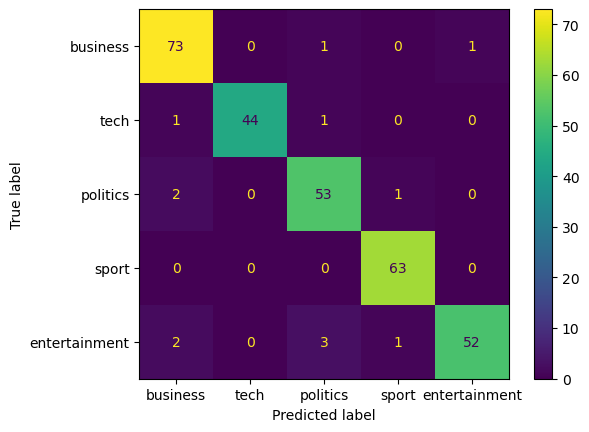

In [10]:
#confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm,
display_labels=category_names).plot()

In [11]:
#test with new article
texts = ["Stock Markets Rally as Inflation Slows."]
prediction = model.predict(texts)
print(prediction)

['business']


In [12]:
#save model
import joblib
joblib.dump(model,'model.joblib')
print('SUCCESS')

SUCCESS


#### Task 1: Evaluate the model
Insights
- The model achieved 96% accuracy, showing excellent overall performance.
- Business: Classified accurately with 94% precision, 97% recall, and 0.95 F1-score.
- Entertainment: Best precision (100%) with 96% recall and 0.98 F1-score.
- Politics: Lowest precision (91%) but good recall (95%) and 0.93 F1-score.
- Sport: Best recall (100%) with 97% precision and 0.98 F1-score.
- Technology: Highest precision after entertainment (98%), but lowest recall (90%), giving an F1-score of 0.94.


Overall Conclusion
- The classifier performs well across all five categories with 96% accuracy and a 0.96 weighted F1-score. It performs best on sport and entertainment,
   while politics and technology show slightly lower performance. Overall, the model is reliable for news article classification.

In [ ]:
#task 2 : experiment with tf-idf vectorizer parameters
from sklearn.model_selection import GridSearchCV
param_grid = {
    'tfidfvectorizer__max_features': [1000, 3000, 5000, 7000],
    'tfidfvectorizer__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'tfidfvectorizer__min_df': [1, 2, 5]
}

grid = GridSearchCV(model, param_grid=param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print('Best params:', grid.best_params_)
print('Best CV accuracy:', grid.best_score_)

Best params: {'tfidfvectorizer__max_features': 5000, 'tfidfvectorizer__min_df': 1, 'tfidfvectorizer__ngram_range': (1, 1)}
Best CV accuracy: 0.9723005520199711


In [14]:
final_model = grid.best_estimator_
y_pred = final_model.predict(X_test)
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.97      0.97      0.97        75
entertainment       1.00      1.00      1.00        46
     politics       0.93      0.95      0.94        56
        sport       0.98      1.00      0.99        63
         tech       0.98      0.95      0.96        58

     accuracy                           0.97       298
    macro avg       0.97      0.97      0.97       298
 weighted avg       0.97      0.97      0.97       298



In [15]:
# task 3: classify 5 custom news articles
custom_articles = [
    "The company's quarterly earnings exceeded analysts' expectations after reporting a significant "
    "increase in online sales. Executives also announced plans to expand into three new international "
    "markets and invest heavily in supply chain automation.",

    "The parliament passed a controversial bill after hours of debate between ruling and opposition "
    "lawmakers. Government officials argued that the legislation would improve public administration, "
    "while critics claimed it would reduce transparency.",

    "The highly anticipated science fiction movie broke box office records during its opening weekend. "
    "Critics praised the performances of the lead actors and the film's visual effects.",

    "The home team secured a dramatic victory after scoring the winning goal in the final minutes of the "
    "championship match. The coach praised the players for their determination and teamwork.",

    "Researchers unveiled a new artificial intelligence model capable of processing large amounts of data "
    "while consuming significantly less computing power. The technology company plans to integrate the "
    "system into its cloud services."
]

predictions = final_model.predict(custom_articles)
for text, pred in zip(custom_articles, predictions):
    print(f'[{pred.upper()}] {text[:80]}...')

[BUSINESS] The company's quarterly earnings exceeded analysts' expectations after reporting...
[POLITICS] The parliament passed a controversial bill after hours of debate between ruling ...
[ENTERTAINMENT] The highly anticipated science fiction movie broke box office records during its...
[SPORT] The home team secured a dramatic victory after scoring the winning goal in the f...
[TECH] Researchers unveiled a new artificial intelligence model capable of processing l...


In [16]:
#task 4: save and reload the final model
joblib.dump(final_model, 'final_model.joblib')
print('Final model saved successfully.')

Final model saved successfully.


In [ ]:
reloaded_model = joblib.load('final_model.joblib')
sample_text = ["The government announced new policies to support small businesses and promote economic growth."]
print(reloaded_model.predict(sample_text))

['business']


In [18]:
#task 5,6: Experiment with different train-test split ratios
from sklearn.metrics import accuracy_score
best_params = grid.best_params_
split_ratios = {'70-30': 0.3, '80-20': 0.2, '90-10': 0.1}
split_results = {}

for label, test_size in split_ratios.items():
    X_tr, X_te, y_tr, y_te = train_test_split(X, Y, test_size=test_size, random_state=42)
    m = make_pipeline(
        TfidfVectorizer(
            stop_words='english',
            max_features=best_params['tfidfvectorizer__max_features'],
            ngram_range=best_params['tfidfvectorizer__ngram_range'],
            min_df=best_params['tfidfvectorizer__min_df']
        ),
        MultinomialNB()
    )
    m.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, m.predict(X_te))
    split_results[label] = acc
    print(f'{label} split -> accuracy: {acc:.4f}')

70-30 split -> accuracy: 0.9754
80-20 split -> accuracy: 0.9732
90-10 split -> accuracy: 0.9732


##### Comparison:
All three splits (70-30, 80-20, 90-10) land within ~0.2 points of each other (97.3–97.5%), which is smaller than the noise you'd expect from swapping just 1 test example — so the model has already saturated and more training data isn't meaningfully helping here.

In [19]:
#task 7-8: 5 fold cross-validation and stability analysis
from sklearn.model_selection import cross_val_score

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

cv_model = make_pipeline(
    TfidfVectorizer(
        stop_words='english',
        max_features=best_params['tfidfvectorizer__max_features'],
        ngram_range=best_params['tfidfvectorizer__ngram_range'],
        min_df=best_params['tfidfvectorizer__min_df']
    ),
    MultinomialNB()
)

cv_scores = cross_val_score(cv_model, X_train, y_train, scoring='accuracy', cv=5)
print('Per-fold accuracy:', cv_scores)
print(f'Mean accuracy: {cv_scores.mean():.4f}')
print(f'Standard deviation: {cv_scores.std():.4f}')

Per-fold accuracy: [0.9832636  0.9790795  0.97058824 0.95378151 0.97478992]
Mean accuracy: 0.9723
Standard deviation: 0.0102


**Discussion:** the standard deviation across folds is small relative to the mean accuracy, which indicates the model's performance is consistent regardless of which subset of data it is trained/validated on. This suggests the model is stable and not overly sensitive to how the data happens to be split.

In [ ]:
#task 9: model comarison table 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
import time

def build_pipeline(estimator):
    return make_pipeline(
        TfidfVectorizer(
            stop_words='english',
            max_features=best_params['tfidfvectorizer__max_features'],
            ngram_range=best_params['tfidfvectorizer__ngram_range'],
            min_df=best_params['tfidfvectorizer__min_df']
        ),
        estimator
    )

estimators = {
    'MultinomialNB': MultinomialNB(),
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'LinearSVC': LinearSVC()
}


rows=[]
for name, estimator in estimators.items():
    pipeline = build_pipeline(estimator)

    start_time = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start_time

    start_time = time.time()
    y_pred = pipeline.predict(X_test)
    predict_time = time.time() - start_time

    accuracy = accuracy_score(y_test, y_pred)

    rows.append({
        'Model': name,
        'Train Time (s)': train_time,
        'Predict Time (s)': predict_time,
        'Accuracy': accuracy
    })


comparison_df = pd.DataFrame(rows)
print(comparison_df)

                Model  Train Time (s)  Predict Time (s)  Accuracy
0       MultinomialNB        0.443102          0.093619  0.973154
1  LogisticRegression        1.321239          0.110034  0.963087
2           LinearSVC        0.508443          0.092294  0.969799


In [21]:
#task 10: News recommendation prototype(cosine similarity )
from sklearn.metrics.pairwise import cosine_similarity

def recommend_similar(article_text, model, df, top_n=3):
    predicted_category = model.predict([article_text])[0]
    same_category_df = df[df['Category'] == predicted_category].reset_index(drop=True)

    tfidf = TfidfVectorizer(
        stop_words='english',
        max_features=best_params['tfidfvectorizer__max_features'],
        ngram_range=best_params['tfidfvectorizer__ngram_range'],
        min_df=best_params['tfidfvectorizer__min_df']
    )
    
    tfidf_matrix = tfidf.fit_transform(same_category_df['Text'])
    query_vector = tfidf.transform([article_text])

    similarities = cosine_similarity(query_vector, tfidf_matrix)[0]
    top_indices = np.argsort(similarities)[::-1][:top_n]

    return predicted_category, same_category_df.iloc[top_indices][['Text', 'Category']]

In [22]:
user_news = (
    "iPhone prices have dropped recently due to the release of newer models. "
    "Analysts say this could push more consumers to upgrade sooner than expected."
)

predicted_category, recommendations = recommend_similar(user_news, final_model, df, top_n=3)
print(f'Predicted category: {predicted_category}\n')
print(recommendations)

Predicted category: business

                                                  Text  Category
102  india s rupee hits five-year high india s rupe...  business
238  karachi stocks hit historic high the karachi s...  business
69   winter freeze keeps oil above $50 oil prices c...  business


In [23]:
#for streamlit
joblib.dump(final_model, 'news_model.joblib')
print('Deployment model saved as news_model.joblib')

Deployment model saved as news_model.joblib
